<a href="https://colab.research.google.com/github/banteamlak1888/Floridan-University-Fundamentals-AI-Trianing/blob/main/Customer_Feedback_Sentiment_Analysis_Using_Embedding_%2B_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Deep Learning for Natural Language Processing project**

**Customer Feedback Sentiment Analysis Using Embedding + LSTM**

**Step 1: Upload and Read Dataset**

This allows you to upload:

customer_feedback_sentiment_large_dataset.csv

In [ ]:
# Import file upload tool from Google Colab
from google.colab import files

# Upload the CSV dataset
uploaded = files.upload()

Saving customer_feedback_sentiment_large_dataset.csv to customer_feedback_sentiment_large_dataset.csv


This loads the dataset into a table.

In [ ]:
# Import pandas for data handling
import pandas as pd

# Read the dataset
data = pd.read_csv("customer_feedback_sentiment_large_dataset.csv")

# Show first five rows
print(data.head())

                                            feedback sentiment
0     The staff were friendly and helped me quickly.  positive
1  The digital payment platform is easy to use an...  positive
2  I trust the bank because the branch service is...  positive
3    The staff were inefficient and did not help me.  negative
4   The ATM system is easy to use and very reliable.  positive


**Step 2: Import Required Libraries**

These libraries help us clean text, convert text into numbers, build a deep learning model, train it, and evaluate it.

In [ ]:
# Import NumPy for numerical operations
import numpy as np

# Import regular expressions for text cleaning
import re

# Import Matplotlib for visualization
import matplotlib.pyplot as plt

# Import train_test_split for splitting the dataset
from sklearn.model_selection import train_test_split

# Import LabelEncoder to convert text labels into numbers
from sklearn.preprocessing import LabelEncoder

# Import evaluation tools
from sklearn.metrics import confusion_matrix, classification_report

# Import TensorFlow for deep learning
import tensorflow as tf

# Import Keras tools
from tensorflow import keras
from tensorflow.keras import layers

# Import tokenizer for converting text into integer sequences
from tensorflow.keras.preprocessing.text import Tokenizer

# Import pad_sequences to make all text sequences the same length
from tensorflow.keras.preprocessing.sequence import pad_sequences

**Step 3: Inspect Dataset**

Before training, we check:
*  number of rows
*  column names
*  missing values
*  class balance



In [ ]:
# Show dataset shape
print("Dataset shape:", data.shape)

# Show column names
print("Columns:", data.columns.tolist())

# Check missing values
print(data.isnull().sum())

# Show number of positive and negative feedback comments
print(data["sentiment"].value_counts())

Dataset shape: (3200, 2)
Columns: ['feedback', 'sentiment']
feedback     0
sentiment    0
dtype: int64
sentiment
positive    1600
negative    1600
Name: count, dtype: int64


**Step 4: Visualize Sentiment Distribution**

This helps see whether the dataset is balanced.

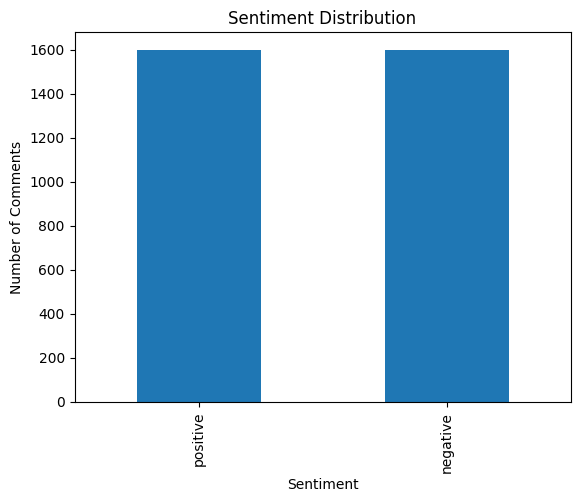

In [ ]:
# Plot sentiment distribution
data["sentiment"].value_counts().plot(kind="bar")

# Add title
plt.title("Sentiment Distribution")

# Add x-axis label
plt.xlabel("Sentiment")

# Add y-axis label
plt.ylabel("Number of Comments")

# Show plot
plt.show()

**Step 5: Clean the Text**

This prepares text for deep learning.

In [ ]:
# Define text cleaning function
def clean_text(text):

    # Convert text to lowercase
    text = text.lower()

    # Remove characters that are not letters or spaces
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    # Return cleaned text
    return text

This creates a cleaned version of each feedback comment.

In [ ]:
# Apply cleaning function to feedback column
data["clean_feedback"] = data["feedback"].apply(clean_text)

# Show original and cleaned feedback
print(data[["feedback", "clean_feedback"]].head())

                                            feedback  \
0     The staff were friendly and helped me quickly.   
1  The digital payment platform is easy to use an...   
2  I trust the bank because the branch service is...   
3    The staff were inefficient and did not help me.   
4   The ATM system is easy to use and very reliable.   

                                      clean_feedback  
0      the staff were friendly and helped me quickly  
1  the digital payment platform is easy to use an...  
2  i trust the bank because the branch service is...  
3     the staff were inefficient and did not help me  
4    the atm system is easy to use and very reliable  


**Step 6: Encode Labels**

Deep learning models need numeric labels.
Usually:
*  negative = 0
*  positive = 1

In [ ]:
# Create label encoder
label_encoder = LabelEncoder()

# Convert sentiment labels into numeric values
data["sentiment_encoded"] = label_encoder.fit_transform(data["sentiment"])

# Show label mapping
print("Classes:", label_encoder.classes_)

# Show first few encoded values
print(data[["sentiment", "sentiment_encoded"]].head())

Classes: ['negative' 'positive']
  sentiment  sentiment_encoded
0  positive                  1
1  positive                  1
2  positive                  1
3  negative                  0
4  positive                  1


**Step 7: Separate Text and Target**

*  X_text contains the input text.
*  y contains the target sentiment.

In [ ]:
# Store cleaned feedback text
X_text = data["clean_feedback"]

# Store encoded sentiment labels
y = data["sentiment_encoded"]

**Step 8: Split Dataset**  
*  80% is used for training.
*  20% is used for testing.
*  **stratify=y** keeps positive/negative balance in both sets.

In [ ]:
# Split dataset into training and testing parts
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

**Step 9: Understanding Tokenization**

Neural networks cannot understand words directly.

They only understand numbers.

Therefore, we must convert words into numerical representations.

This process is called Tokenization.

**Create the Tokenizer**

Tokenization converts words into numbers.

In [ ]:
# Define vocabulary size
vocab_size = 5000

# Define unknown word token
oov_token = "<OOV>"

# Create tokenizer
tokenizer = Tokenizer(
    num_words=vocab_size,
    oov_token=oov_token
)

# Learn vocabulary from training text only
tokenizer.fit_on_texts(X_train_text)

**Step 10: Convert Text to Sequences**

Each feedback comment becomes a list of numbers.

In [ ]:
# Convert training text into sequences of integers
X_train_seq = tokenizer.texts_to_sequences(X_train_text)

# Convert testing text into sequences of integers
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

**Step 11: Pad Sequences**

*  Neural networks need inputs of the same length.

*  Short comments are padded with zeros.
*  Long comments are cut to 30 words.

In [ ]:
# Define maximum sequence length
max_length = 30

# Pad training sequences
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

# Pad testing sequences
X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

**Step 12: Understanding Word Embeddings**

Before building the model, let's understand one of the most powerful concepts in Natural Language Processing.

Word Embeddings.

Traditional tokenization converts words into numbers.

**Step 13: Build Deep Learning Model**
*  **Embedding** learns word meanings as vectors.
*  **LSTM** learns word order and sequence patterns.
*  **Dropout** helps prevent memorization.
*  **Dense** helps classification.
*  **Sigmoid** outputs probability of positive sentiment.

In [ ]:
# Build deep learning model
model = keras.Sequential([

    # Input layer tells the model the length of each text sequence
    layers.Input(shape=(max_length,)),

    # Embedding layer converts word numbers into dense vectors
    layers.Embedding(
        input_dim=vocab_size,
        output_dim=64
    ),

    # LSTM layer learns sequence patterns in text
    layers.LSTM(64),

    # Dropout helps reduce overfitting
    layers.Dropout(0.3),

    # Dense hidden layer
    layers.Dense(32, activation="relu"),

    # Output layer for binary classification
    layers.Dense(1, activation="sigmoid")
])

**Step 14: Understanding LSTM Networks**

Now, let's understand why we use LSTM.

LSTM stands for Long Short-Term Memory.

Traditional neural networks struggle with sequential information.

**Step 15: Compile Model**
*  adam updates model weights.
*  binary_crossentropy is used for positive/negative classification.
*  accuracy measures correct predictions.

In [ ]:
# Compile the model
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

**Step 16: View Model Summary**

This shows layers, output shapes, and trainable parameters.

In [ ]:
# Show model architecture
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 30, 64)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,137 (1.35 MB)

 Trainable params: 355,137 (1.35 MB)

 Non-trainable params: 0 (0.00 B)

**Step 17: Add Early Stopping**

Early stopping stops training when validation loss stops improving.

This helps reduce overfitting.


In [ ]:
# Create early stopping callback
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

**Step 18: Train Model**
*  **X_train_pad** is the numerical text input.
*  **y_train** is the sentiment label.
*  **validation_split=0.2** monitors performance during training.
*  **epochs=10** trains for up to 10 rounds.
*  **early stopping** may stop training earlier.

In [ ]:
# Train the deep learning model
history = model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.9585 - loss: 0.1732 - val_accuracy: 0.9316 - val_loss: 0.2962
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.9023 - loss: 0.3018 - val_accuracy: 0.9277 - val_loss: 0.2150
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9336 - loss: 0.2115 - val_accuracy: 0.9414 - val_loss: 0.1850
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9502 - loss: 0.1809 - val_accuracy: 0.9414 - val_loss: 0.1869
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9434 - loss: 0.2266 - val_accuracy: 0.9004 - val_loss: 0.2872
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9150 - loss: 0.2528 - val_accuracy: 0.8984 - val_loss: 0.2803


**Step 19: Evaluate Model**

This measures performance on unseen feedback comments.

In [ ]:
# Evaluate model on test data
test_loss, test_accuracy = model.evaluate(X_test_pad, y_test)

# Print results
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9125 - loss: 0.2805
Test Loss: 0.2804802358150482
Test Accuracy: 0.9125000238418579


**Step 20: Plot Accuracy**

This shows whether the model improves over time.

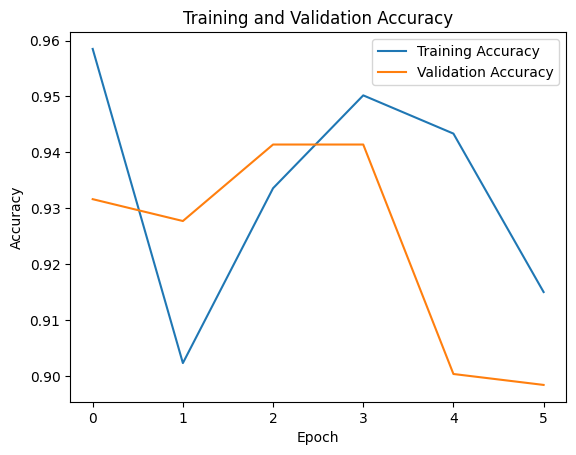

In [ ]:
# Plot training accuracy
plt.plot(history.history["accuracy"], label="Training Accuracy")

# Plot validation accuracy
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

# Add title
plt.title("Training and Validation Accuracy")

# Add labels
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

# Add legend
plt.legend()

# Show plot
plt.show()

**Step 21: Plot Loss**

Loss shows model error. If validation loss increases while training loss decreases, the model may be overfitting.

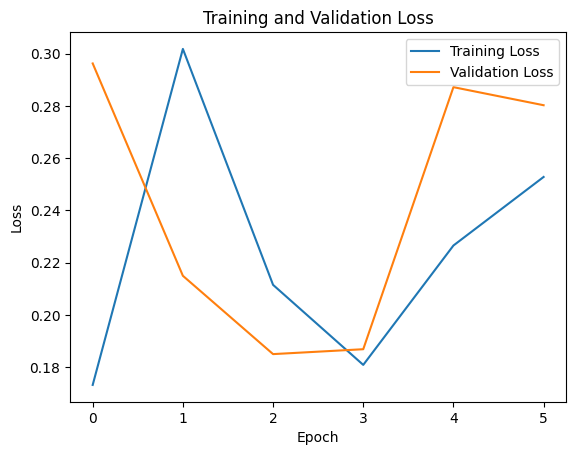

In [ ]:
# Plot training loss
plt.plot(history.history["loss"], label="Training Loss")

# Plot validation loss
plt.plot(history.history["val_loss"], label="Validation Loss")

# Add title
plt.title("Training and Validation Loss")

# Add labels
plt.xlabel("Epoch")
plt.ylabel("Loss")

# Add legend
plt.legend()

# Show plot
plt.show()

**Step 22: Make Predictions**

The model outputs probabilities:
*  above 0.5 = positive
*  0.5 or below = negative

In [ ]:
# Predict probabilities on test data
y_pred_prob = model.predict(X_test_pad)

# Convert probabilities into binary labels
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


**Step 23: Confusion Matrix**

The confusion matrix shows:
*  correct negative predictions
*  wrong negative predictions
*  wrong positive predictions
*  correct positive predictions

In [ ]:
# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Print confusion matrix
print(cm)

[[316   4]
 [ 52 268]]


**Step 24: Classification Report**

This shows precision, recall, and F1-score for each sentiment class.

In [ ]:
# Print classification report
print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

    negative       0.86      0.99      0.92       320
    positive       0.99      0.84      0.91       320

    accuracy                           0.91       640
   macro avg       0.92      0.91      0.91       640
weighted avg       0.92      0.91      0.91       640



**Step 25: Predict New Feedback**



In [ ]:
# Take 10 feedback comments from the test dataset
sample_texts = X_test_text.iloc[:10]

# Take the actual labels for those 10 comments
actual_labels = y_test.iloc[:10]

# Convert the 10 feedback comments into sequences
sample_sequences = tokenizer.texts_to_sequences(sample_texts)

# Pad the sequences so all have the same length
sample_padded = pad_sequences(
    sample_sequences,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

# Predict sentiment probabilities
sample_probabilities = model.predict(sample_padded)

# Convert probabilities into class labels
sample_predictions = (sample_probabilities > 0.5).astype(int).flatten()

# Convert numeric labels back to text labels
predicted_sentiments = label_encoder.inverse_transform(sample_predictions)

# Convert actual numeric labels back to text labels
actual_sentiments = label_encoder.inverse_transform(actual_labels)

# Create a result table
prediction_results = pd.DataFrame({
    "Feedback": sample_texts.values,
    "Actual Sentiment": actual_sentiments,
    "Predicted Sentiment": predicted_sentiments,
    "Prediction Probability": sample_probabilities.flatten()
})

# Show result
print(prediction_results)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step
                                            Feedback Actual Sentiment  \
0  the customer support service is slow confusing...         negative   
1                 the service at the branch was poor         negative   
2   the branch service was very excellent and simple         positive   
3  i do not trust the bank because the loan appli...         negative   
4        the service at the mobile app was excellent         positive   
5  i dislike the agent banking option because it ...         negative   
6  the service at the customer service desk was e...         positive   
7      the bank did not solve my card issue properly         negative   
8  i trust the bank because the branch service is...         positive   
9  i dislike the queue management system because ...         negative   

  Predicted Sentiment  Prediction Probability  
0            negative                0.098467  
1            negative                0.098438  
2            

**Step 26: Save Model and Tokenizer**

This saves the deep learning model.

In [ ]:
# Save trained model
model.save("customer_feedback_lstm_model.keras")

**Step 27: Save Tokenizer**

In [ ]:
import pickle

with open(
    "tokenizer.pkl",
    "wb"
) as handle:

    pickle.dump(
        tokenizer,
        handle
    )

**Step 28: Project Summary**